In [1]:
BasePath = joinpath(homedir(),"jupyter","julia","sivers") 
ModulePath = joinpath(BasePath,"sivers.jl") 
include(ModulePath)
using .Sivers

# Parameters handled separately
ParametersPath = joinpath(BasePath,"parameters.jl")
include(ParametersPath)
using .parameters: params
# # Parameters and SU(Nc) algebra set in parameters.jl
alpha_s = params.alpha_s
Nc = params.Nc
mN = params.mN
mq = params.mq
dabc2 = (Nc^2 - 4) * (Nc^2 - 1) / Nc ;

In [ ]:
# Test spin sums in forward limit
function test_spin_sum(s01,s02)
    # Initialize wavefunctions
    swf1 = Array{ComplexF64}(undef, 2, 2, 2)
    swf2 = Array{ComplexF64}(undef, 2, 2, 2)
    x = rand(2) 
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Forward limit
    k1, k2, k3 = [0,0], [0,0], [0,0]

    for s1 in (-1,1), s2 in (-1,1), s3 in (-1,1)
        i1 = hp.spin_index(s1)
        i2 = hp.spin_index(s2)
        i3 = hp.spin_index(s3)
        swf1[i1,i2,i3] = spin_wavefunction(s01,s1,s2,s3,k1, k2, k3, x1, x2, x3)
        swf2[i1,i2,i3] = spin_wavefunction(s02,s1,s2,s3,k1, k2, k3, x1, x2, x3)
    end
    result = spin_sum(swf1,swf2)
    return result
end
# Should be 1 in forward limit
println(test_spin_sum(1,1))
# Should be 0 in forward limit
println(test_spin_sum(1,-1))

1.0000000000000002 + 0.0im
0.0 + 0.0im


In [41]:
function test(x)
    s01, s02 = 1, -1
    Δ = [.2,0]
    function integrand(x)
        eu, ed = 2/3, -1/3
        charges = (eu,eu,ed)
        # (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        x1, x2, x3 = 1/3, 1/3, 1/3
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        # Jacobian
        # d4k = d2k1 * d2k2
        # println("sumx ",x1+x2+x3)
        println(r1," ", ϕ1)
        println(r2," ", ϕ2)
        
        # println("k1 ",k1)
        # println("k2 ",k2)
        # println("sumk ",k1+k2+k3)
        # println("jacs ",d4k," ",d2x)

        total = 0
        wf1 = compute_wavefunction(s01,k1,k2,k3,x1,x2,x3)
        # Sum over charge contributions
        for (i,q) in enumerate(charges)
            k1prime = k1 - x1 * Δ + hp.kronecker_delta(i,1) * Δ
            k2prime = k2 - x2 * Δ + hp.kronecker_delta(i,2) * Δ
            k3prime = k3 - x3 * Δ + hp.kronecker_delta(i,3) * Δ
            println("i=$i")
            # println(k1prime)
            # println(k2prime)
            # println(k3prime)
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum over spin contributions
            tmp = spin_sum(wf1,wf2)
            println(tmp)
            total += tmp
        end
        res = total
        return res
    end
    result = integrand(x)
    return result
end
test(rand(6))

0.3283912930351958 0.6044727006927687
0.0544303390882424 6.1354746660385935
i=1
-363099.4762771427 - 194817.11747171168im
i=2
-490715.17880398856 - 286754.410615172im
i=3
-1.1319235538643913e6 - 835832.1594394946im


-1.9857382089455226e6 - 1.3174036875263783e6im

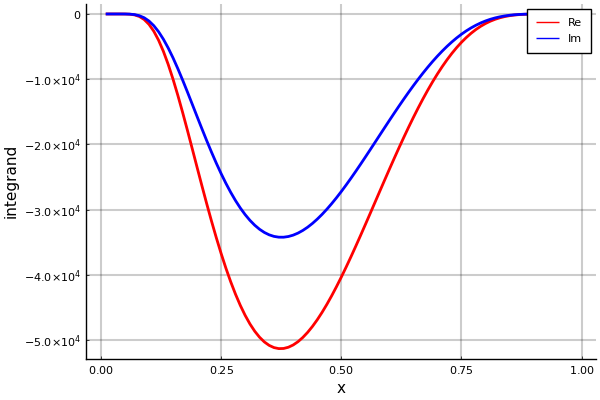

In [63]:
function test_(x)
    s01, s02 = 1, -1
    Δ = [.2,0]
    function integrand(x)
        eu, ed = 2/3, -1/3
        charges = (eu,eu,ed)
        # over x1
        xx = [x,1/3]
        (x1, _, x3), d2x = hp.cuba_to_parton_x(xx[1:2])
        r1, ϕ1 = 0.3283912930351958, 0.6044727006927687    # k1
        r2, ϕ2 = 0.0544303390882424, 6.1354746660385935
        # over r1
        # x1, x2, x3 = 1/3, 1/3, 1/3
        # r1, ϕ1 = x / (1-x), 0.6044727006927687    # k1
        # r2, ϕ2 = 0.0544303390882424, 6.1354746660385935
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        total = 0
        wf1 = compute_wavefunction(s01,k1,k2,k3,x1,x2,x3)
        # Sum over charge contributions
        for (i,q) in enumerate(charges)
            k1prime = k1 - x1 * Δ + hp.kronecker_delta(i,1) * Δ
            k2prime = k2 - x2 * Δ + hp.kronecker_delta(i,2) * Δ
            k3prime = k3 - x3 * Δ + hp.kronecker_delta(i,3) * Δ
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum over spin contributions
            total += spin_sum(wf1,wf2)
        end
        res = total * r1 * r2 * d2x
        return res
    end
    result = integrand(x)
    return result
end

using Plots
pyplot()

x_vals = 0:0.01:1
results = ComplexF64[]
for x in x_vals
    push!(results, test_(x))
end
plot(x_vals, real.(results),
    label="Re",              # Label for the data series
    xlabel="x",             # Label for the x-axis
    ylabel="integrand",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    # yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)
plot!(x_vals, imag.(results),
    label="Im",
    linewidth=2,
    linecolor=:blue)

In [ ]:
0.3283912930351958 0.6044727006927687
0.0544303390882424 6.1354746660385935

In [16]:
Δ_array = 0:.1:1
n = length(Δ_array)
# Initialize array
results_ud = Vector{ComplexF64}(undef, n)
results_du = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results_ud[i] = f_form_factor(-1,1,[Δ/sqrt(2),Δ/sqrt(2)])
end
println(results_ud)
for i in 1:n
    Δ = Δ_array[i]
    results_du[i] = f_form_factor(1,-1,[Δ/sqrt(2),Δ/sqrt(2)])
end
println(results_du)

ComplexF64[-0.00039607545156321306 - 2.139988140647371e-17im, 0.00012917504210476017 + 0.0003903699765786936im, -0.0005735892558495532 + 0.000542533337605324im, -0.0002189383742915833 + 0.0008583709984178676im, -6.421436498229744e-6 + 0.007452045558767202im, 0.00023452429874368838 + 0.00046015751992564387im, 0.00019119354127493618 + 0.0007959552685893849im, 4.857387174033103e-5 + 0.00027245283380808585im, -8.786766389414057e-5 + 0.00014878845713333548im, -0.00010108651505699312 + 0.00014819492683465003im, -0.0001021175847288968 - 1.0747667435588845e-5im]
ComplexF64[-0.00039607545156321306 + 2.139988140647371e-17im, 0.0001291750421047934 - 0.00039036997657870674im, -0.0005735892558495245 - 0.0005425333376052884im, -0.00021893837429148708 - 0.0008583709984179522im, -6.421436498225665e-6 - 0.0074520455587672035im, 0.00023452429874369532 - 0.00046015751992565883im, 0.00019119354127493965 - 0.000795955268589223im, 4.857387174035195e-5 - 0.0002724528338080034im, -8.786766389413142e-5 - 0.000

In [25]:
ΔL, ΔR, results = Vector{ComplexF64}(undef, n), Vector{ComplexF64}(undef, n), Vector{ComplexF64}(undef, n)
Δ2, mN = sum(Δ_array.^2), 0.9382
for i in 1:n
    ΔL[i], ΔR[i] = complex(Δ_array[i],-Δ_array[i]) / 2, complex(Δ_array[i],Δ_array[i]) / 2
    # results[i] = 2 * mN^2 / Δ2 * (ΔL[i] / mN * results_du[i] - ΔR[i] / mN * results_ud[i])
end
results = 2 * mN / Δ2 * (ΔL .* results_du + ΔR .* results_ud)
println(results)

ComplexF64[0.0 + 0.0im, -1.273003052069792e-5 - 1.129486621926162e-18im, -0.00010879441217447645 + 3.3356183863901275e-19im, -0.00015751662132093528 - 1.3210369847089614e-17im, -0.0014540329838873824 - 5.2841479388358455e-19im, -5.498417873062712e-5 - 2.668494709112102e-18im, -0.000176848037163534 + 2.3144567972101006e-17im, -7.637936080433423e-5 + 1.0495638843512699e-17im, -9.227252893422089e-5 + 1.9155036278279942e-19im, -0.00010934455267764718 + 1.3243395771707338e-18im, -4.4531561768611526e-5 + 4.0952146525977808e-19im]


# $F_2$ form factor

In [ ]:
# Something's fishy already here...check this
# probably a sign error

In [82]:
using Cuba
function f_form_factor_(s01::Integer,s02::Integer,Δ::Vector{<:Real})
    eu, ed = 2/3, -1/3
    charges = (eu,eu,ed)
    function integrand(x,f)
        (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        # Jacobian
        d4k = d2k1 * d2k2

        total = 0
        wf1 = compute_wavefunction(s01,k1,k2,k3,x1,x2,x3)
        # Sum over charge contributions
        for (i,q) in enumerate(charges)
            k1prime = k1 - x1 * Δ + hp.kronecker_delta(i,1) * Δ
            k2prime = k2 - x2 * Δ + hp.kronecker_delta(i,2) * Δ
            k3prime = k3 - x3 * Δ + hp.kronecker_delta(i,3) * Δ
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum over spin contributions
            total += q * spin_sum(wf1,wf2)
        end
        res = total * d4k * d2x
        f[1] = real(res)
        f[2] = imag(res)
    end
    # Call cuhre with ncomp=2 to track real and imaginary parts separately
    integral, err = cuhre(integrand, 6, 2, atol=1e-12, rtol=1e-10);
    # integral, err = cuhre(integrand, 6, 2; atol=1e-12, rtol=1e-10, maxevals=1e7)
    # integral, err = vegas(integrand, 6, 2; atol=1e-12, rtol=1e-10, maxevals=1e7)
    # integral, err = suave(integrand, 6, 2;
    #                   atol=1e-10, rtol=1e-8,
    #                   maxevals=Int(1e7), nnew=Int(1e5), flatness=50)

    # Reconstruct complex result and
    # multiply with prefactors from integration
    println("Re =", integral[1], " ± ", err[1])
    println("Im =", integral[2], " ± ", err[2])
end
f_form_factor_(1,1,Δ)

Re =14162.184309305334 ± 97.91982033093667
Im =1.2059418665755955e-13 ± 2.2002860701150195e-13


In [85]:
using MCIntegration
function f_form_factor_mc(s01::Integer,s02::Integer,Δ::Vector{<:Real})
    eu, ed = 2/3, -1/3
    charges = (eu,eu,ed)
    function integrand(x,c)
        (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2

        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        # Jacobian
        d4k = d2k1 * d2k2

        total = 0
        wf1 = compute_wavefunction(s01,k1,k2,k3,x1,x2,x3)
        # Sum over charge contributions
        for (i,q) in enumerate(charges)
            k1prime = k1 - x1 * Δ + hp.kronecker_delta(i,1) * Δ
            k2prime = k2 - x2 * Δ + hp.kronecker_delta(i,2) * Δ
            k3prime = k3 - x3 * Δ + hp.kronecker_delta(i,3) * Δ
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum over spin contributions
            total += q * spin_sum(wf1,wf2)
        end
        res = total * d4k * d2x
        return (real(res), imag(res))
    end

    var = Continuous(0.0, 1.0)
    result = integrate(integrand; var, dof = [[6,],[6,]], print=-1, solver=:vegas, neval = 5e6)
end
f_form_factor_mc(1,-1,[1,0])


Total iterations * blocks 160: 100%|██████| Time: 0:33:51 (12.70  s/it)


Integral 1 = 0.471056731080265 ± 5.252315033667295   (reduced chi2 = 0.609)
Integral 2 = -6.086278871704733 ± 5.410175945651171   (reduced chi2 = 0.495)

In [ ]:
# neval 1e6 for 1,-1 spin config
# [32mTotal iterations * blocks 160: 100%|██████| Time: 0:06:45 ( 2.53  s/it)[39m
# [32mIntegral 1 = 14.587120797211261 ± 13.417259095784706   (reduced chi2 = 0.608)[0m
# [32mIntegral 2 = 14.477418411250223 ± 14.096784101596644   (reduced chi2 = 1.15)[0m

In [ ]:
Δ = [1,0]
fdu = f_form_factor(1,-1,Δ)
fud = f_form_factor(-1,1,Δ)

In [ ]:
ΔL, ΔR = complex(Δ[1],-Δ[2]) / sqrt(2), complex(Δ[1],Δ[2]) / sqrt(2)
Δ2 = sum(Δ.^2)
result = 2 * mN^2 / Δ2 * (ΔL / mN * fdu - ΔR / mN * fud)
println(result)

-2.5007324264722348e-17 - 1.7755335368382395e-17im


In [ ]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f2_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[NaN + NaN*im, 0.008504613604797253 + 2.5743233963630374e-17im, -5.9941012992728916e-5 + 1.3158929860659489e-17im, -0.016312852760178725 + 9.806946271841356e-18im, -0.0016016953150959849 - 5.171631823050764e-19im, 0.0012934909535739665 + 5.354395816983772e-30im, 0.0017987305558940638 - 1.9290949045193014e-32im, 0.0012546957741499645 - 4.202976973646296e-18im, 0.0011217011042797783 - 2.7127897094802676e-33im, -1.9801045401606664e-5 + 6.5890420264054005e-18im, -2.100830723967007e-5 + 1.0297293585452126e-17im, 9.869052871014902e-6 - 2.674621710507046e-18im, -0.00031439348064932465 + 1.1032814555842695e-17im, -2.466637995222501e-5 + 2.2631414473520985e-18im, 1.5351561539047167e-5 - 1.0507442434144388e-18im, 5.288041660736139e-5 + 9.806946271859184e-19im, 3.231621261493076e-5 + 3.6776048519472e-18im, -2.773842406990878e-5 + 8.653187886934503e-19im, 1.334667263166878e-5 + 6.129341419911909e-19im, -1.0961660442959813e-5 - 1.9355815010244916e-18im, -2.0712942286748047e-5 - 2.02268266

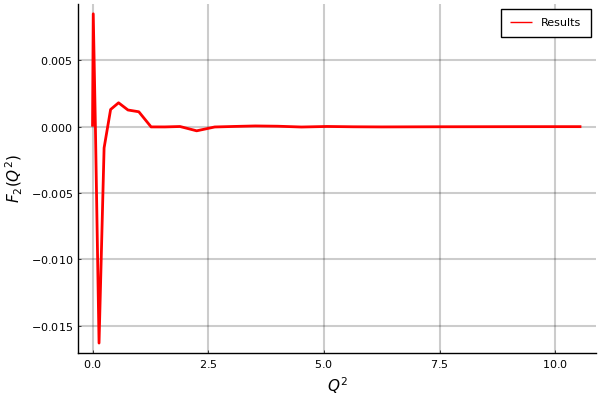

In [ ]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_2(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    # yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

In [ ]:
############################################################################
############################################################################
###   ___  _     _       _          __  __   _          _                ###
###  / _ \| | __| |  ___| |_ _   _ / _|/ _| | |__   ___| | _____      __ ###
### | | | | |/ _` | / __| __| | | | |_| |_  | '_ \ / _ \ |/ _ \ \ /\ / / ###
### | |_| | | (_| | \__ \ |_| |_| |  _|  _| | |_) |  __/ | (_) \ V  V /  ###
###  \___/|_|\__,_| |___/\__|\__,_|_| |_|   |_.__/ \___|_|\___/ \_/\_/   ###
###                                                                      ###
############################################################################
############################################################################

<!--  $F_1$ form factor -->

# $F_1$ form factor

In [ ]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f1_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[1.0000000000000044 + 0.0im, 0.9604490679141829 - 2.018614566574708e-18im, 0.850140286976768 - 8.035573000122411e-19im, 0.7092041767258853 - 1.6452577683509454e-18im, 0.561825672127043 + 7.929997421146725e-19im, 0.42910843161984097 + 2.4274118040275665e-18im, 0.32089306128678813 + 2.940549529951652e-19im, 0.24013004381392203 + 1.1458122591116201e-18im, 0.17262841987798141 + 1.469969846070028e-18im, 0.12392366479880186 + 4.4320561753591435e-18im, 0.08858122725959695 + 3.2525193308682457e-18im, 0.06324049271989429 + 3.2093481258657e-18im, 0.04490346479027737 + 1.0347574952190376e-17im, 0.03139680738800068 + 8.524505193014835e-18im, 0.022185947686009316 + 1.325517624123591e-17im, 0.01606744925762214 + 2.2177049615549194e-17im, 0.011447521703007106 + 2.4049212953564428e-17im, 0.00819399098751722 + 2.4598831414304972e-17im, 0.005851943525568586 + 1.6208172045365398e-17im, 0.004277207798958424 + 1.7774747458882134e-17im, 0.00273776725587325 + 1.277529133406734e-17im, 0.001953952429

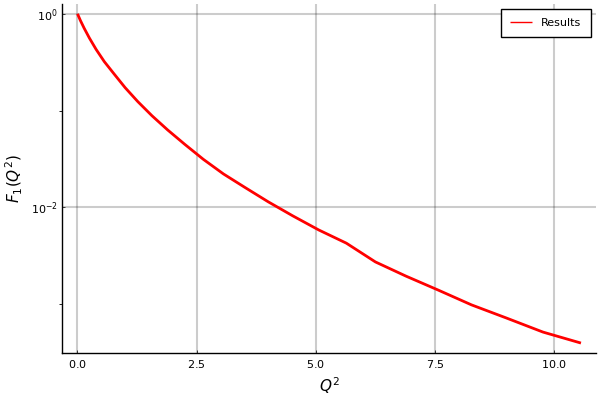

In [52]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_1(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

Proton radius

Linearized result:
  Proton radius R[fm] = 0.7696815452862754
Dipole fit result:
  M_D = 0.577752650493521
  Proton radius R[fm] = 0.8373379573186447
  Uncertainty: M_D^2 ± 0.007040636120621803, R ± 0.04471278170191824


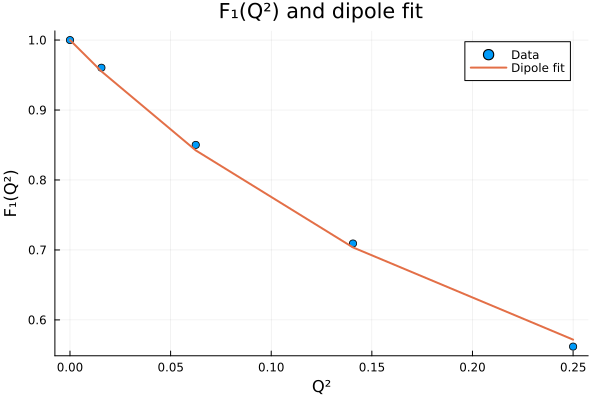

In [ ]:
using LsqFit, Plots
Q2_array = Δ_array.^2
F1 = real(results)

# Linearized derivative
println("Linearized result:")
dF_qQ2 = (F1[2] - F1[1]) / (Q2_array[2] - Q2_array[1])
R = sqrt(-6 * dF) 
println("  Proton radius R[fm] = ", R * hbarc)

# Restrict to Q^2 ≤ Qmax2
Qmax2 = 0.28
mask = Q2_array .<= Qmax2
x = Q2_array[mask]
y = F1[mask]

# Dipole model: p[1] = M_D^2
# model(x,p) = 1.0 ./ (1 .+ x ./ p[1])
# More elegant way to write
@. model(x,p) = 1.0 / (1 + x / p[1])

# Initial guess for M_D^2 (~0.71 GeV^2 for proton)
p0 = [0.7]

fit = curve_fit(model, x, y, p0)

MD2 = fit.param[1]
R = sqrt(6 / MD2) 
hbarc = 0.1975

println("Dipole fit result:")
println("  M_D = ", sqrt(MD2))
println("  Proton radius R[fm] = ", R * hbarc)

# Error estimate
cov = estimate_covar(fit)
σ_MD2 = sqrt(cov[1,1])
σ_R = 0.5 * sqrt(6) * σ_MD2 / (MD2^(3/2))
println("  Uncertainty: M_D^2 ± ", σ_MD2, ", R ± ", σ_R)

F1_fit = model(x, fit.param)

plot(x, y, seriestype=:scatter, label="Data", xlabel="Q²", ylabel="F₁(Q²)",
     title="F₁(Q²) and dipole fit", legend=:topright)
plot!(x, F1_fit, label="Dipole fit", lw=2)


# Benchmark tests

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general

In [ ]:
using Cuba
using BenchmarkTools
"""
    cuba_to_polar(x)

Transform a Cuba sample `x ∈ [0,1]^2` into polar coordinates.

# Arguments
- `x::Vector{<:Real}`: Sample point in the unit circle `[0,1]^2`.

# Returns
- `r::Real`: Radius
- `ϕ::Real`: Azimuthal angle
- `jac::Real`: Jacobian determinant of the transformation

# Notes
Throws an `ArgumentError` if called with `length(x) != 2`.
"""
function cuba_to_polar(x::Vector{<:Real})
    n = length(x)            
    if n != 2
        throw(ArgumentError("Input must be two-dimensional for polar coordinates"))
    end
    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2
    ϕ = 2π * x[2]
    jac = 2π * r * drdx

    return r, ϕ, jac
end

function cuba_to_hyperspherical(x::Vector{<:Real})
    n = length(x)            
    if n < 2
        throw(ArgumentError("Need at least 2 dimensions for hyperspherical coordinates"))
    end

    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2

    thetas = zeros(eltype(x), n-1)

    jac = r^(n-1) * drdx

    # first n-2 angles in [0, π]
    for i in 1:(n-2)
        cosθ = 2*x[i+1] - 1
        θ = acos(cosθ)
        thetas[i] = θ
        jac *= 2 * sin(θ)^(n-i-2)
    end

    # last angle in [0,2π)
    ϕ = 2π * x[n]
    thetas[end] = ϕ
    jac *= 2π

    return r, thetas, jac
end

function integrand(x,f)
    r1, ϕ1, d2k1 = cuba_to_polar(x)
    f[1] = exp(-r1^2) * d2k1
end
@btime integral, err = cuhre(integrand,2,1)
println(integral[1])

function integrand(x,f)
    r1, (ϕ1,), d2k1 = cuba_to_hyperspherical(x)
    f[1] = exp(-r1^2) * d2k1
end

@btime integral, err = cuhre(integrand,2,1)
println(integral[1])


  46.419 μs (2343 allocations: 73.31 KiB)
3.141592697100627
  59.469 μs (2928 allocations: 109.88 KiB)
3.141592697100627
